## Unsupervised Learning
#### by **Ivan Alducin**
<p><img src="https://cdn.gritglobal.io/uploads/too-broad-customer-segmentation.jpg" width="1000"/></p>

## Customer Segmentation
In this chapter, we'll focus on understanding and working with a customer segmentation use case. But before that, here's a short list of other applications that can be used with the data collected from my customers:

- Descriptive Statistics
- Customer Segmentation
- Chutter Prediction
- Customer Lifetime Value (CLV)
  
We'll perform the segmentation using a methodology called RFM (Resource Frequency Modeling).

In [48]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import warnings

warnings.filterwarnings('ignore')

In [49]:
df = pd.read_csv("M30 Online Retail.csv", encoding="latin1", engine="python")
df.head()


,INVOICE_NO,STOCK_CODE,DESCRIPTION,QUANTITY,INVOICE_DATE,UNIT_PRICE,CUSTOMER_ID,REGION
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,01/12/2019 08:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,01/12/2019 08:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,01/12/2019 08:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,01/12/2019 08:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,01/12/2019 08:26,3.39,17850.0,United Kingdom


In [50]:
df['INVOICE_DATE'] = pd.to_datetime(df['INVOICE_DATE'], dayfirst=True, errors='coerce')
df.head()

,INVOICE_NO,STOCK_CODE,DESCRIPTION,QUANTITY,INVOICE_DATE,UNIT_PRICE,CUSTOMER_ID,REGION
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2019-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2019-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2019-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2019-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2019-12-01 08:26:00,3.39,17850.0,United Kingdom


## Recency
<p>Indicator that tells us how recent a customer's purchase is</p>

In [51]:
# Acquire unique customers
customer = df['CUSTOMER_ID'].dropna().unique()
customer[:10]

array([17850., 13047., 12583., 13748., 15100., 15291., 14688., 17809.,
       15311., 14527.])

In [52]:
# Obtener la última fecha de compra por cliente
max_purchase = df.groupby('CUSTOMER_ID')['INVOICE_DATE'].max().reset_index()
max_purchase

,CUSTOMER_ID,INVOICE_DATE
0,12346.0,2020-01-18 10:17:00
1,12347.0,2020-12-07 15:52:00
2,12348.0,2020-09-25 13:13:00
3,12349.0,2020-11-21 09:51:00
4,12350.0,2020-02-02 16:01:00
...,...,...
4367,18280.0,2020-03-07 09:52:00
4368,18281.0,2020-06-12 10:53:00
4369,18282.0,2020-12-02 11:43:00
4370,18283.0,2020-12-06 12:02:00


In [53]:
# Vamos a calcular nuestra metrica de Recency, esto lo haremos 
# restando los días de la última fecha de compra a cada observacón
df['INVOICE_DATE'] = pd.to_datetime(df['INVOICE_DATE'], dayfirst=True, errors='coerce')

df['INVOICE_DATE'].dtype


dtype('<M8[us]')

In [54]:
df['INVOICE_DATE'] = pd.to_datetime(df['INVOICE_DATE'])

reference_date = df['INVOICE_DATE'].max()
max_purchase['RECENCY'] = (reference_date - max_purchase['INVOICE_DATE']).dt.days

In [55]:
# Unir el DataFrame de clientes únicos con el que acabamos de
# crear de la última fecha de compra
customer_df = pd.DataFrame(customer, columns=['CUSTOMER_ID'])
customer = pd.merge(customer_df, max_purchase, on='CUSTOMER_ID')
customer

,CUSTOMER_ID,INVOICE_DATE,RECENCY
0,17850.0,2020-02-10 14:38:00,302
1,13047.0,2020-11-08 12:10:00,31
2,12583.0,2020-12-07 08:07:00,2
3,13748.0,2020-09-05 09:45:00,95
4,15100.0,2020-01-13 17:09:00,330
...,...,...,...
4367,13436.0,2020-12-08 10:33:00,1
4368,15520.0,2020-12-08 10:58:00,1
4369,13298.0,2020-12-08 13:11:00,0
4370,14569.0,2020-12-08 14:58:00,0


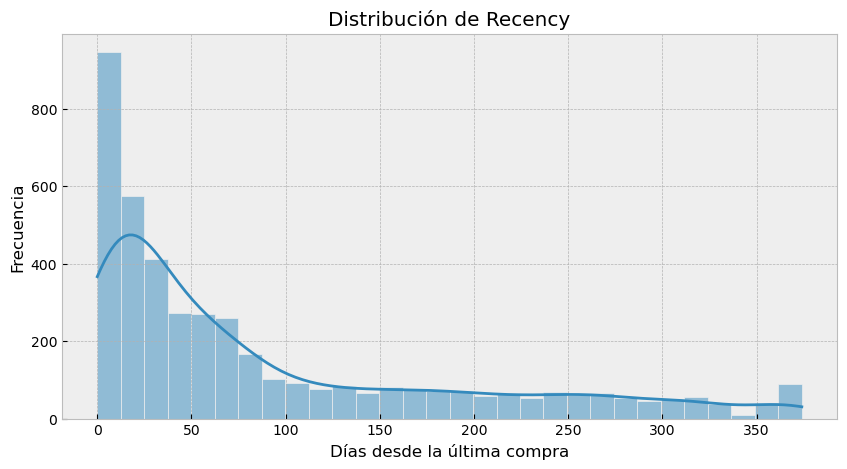

In [56]:
# Grafica un histograma de Recency
plt.figure(figsize=(10,5))
sns.histplot(customer['RECENCY'], bins=30, kde=True)
plt.title('Distribución de Recency')
plt.xlabel('Días desde la última compra')
plt.ylabel('Frecuencia')
plt.show()



In [57]:
# Imprime la Estadística de Resumen para Recency
customer['RECENCY'].describe()

count    4372.000000
mean       91.123056
std       100.946554
min         0.000000
25%        16.000000
50%        49.000000
75%       142.000000
max       374.000000
Name: RECENCY, dtype: float64

# Frequency
<p>Frecuencia con la que un cliente compra uno o más productos</p>

In [58]:
# Obtener el número de compras por cliente
frequency = df.groupby('CUSTOMER_ID')['INVOICE_NO'].nunique().reset_index()
frequency.columns = ['CUSTOMER_ID', 'FREQUENCY']


In [59]:
# Unir el DataFrame que acabamos de crear con el de los clientes unicos
customer = pd.merge(customer, frequency, on='CUSTOMER_ID')

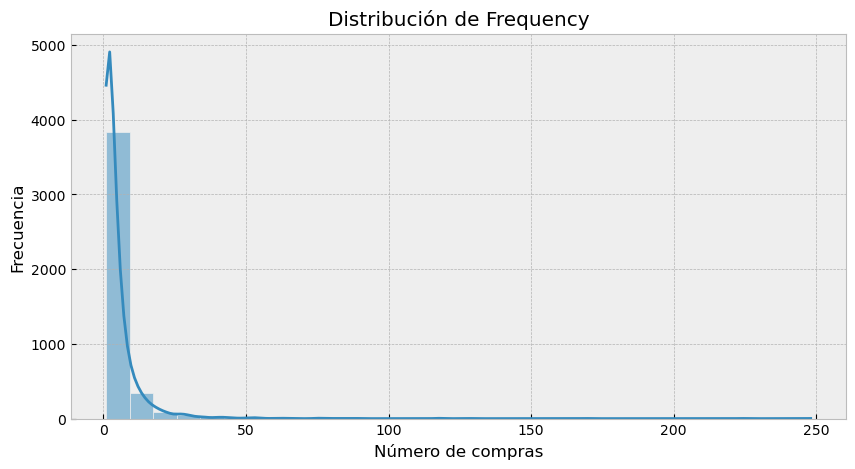

In [60]:
# Grafica un histograma de Frequency
plt.figure(figsize=(10,5))
sns.histplot(customer['FREQUENCY'], bins=30, kde=True)
plt.title('Distribución de Frequency')
plt.xlabel('Número de compras')
plt.ylabel('Frecuencia')
plt.show()


In [61]:
# Imprime la Estadística de Resumen para Frequency
customer['FREQUENCY'].describe()


count    4372.000000
mean        5.075480
std         9.338754
min         1.000000
25%         1.000000
50%         3.000000
75%         5.000000
max       248.000000
Name: FREQUENCY, dtype: float64

# Monetary

In [62]:
# Calcular el monto total por cada compra
df['MONETARY'] = df['QUANTITY'] * df['UNIT_PRICE']
df.head()
# Obtener el valor monetario de compra por cliente
monetary = df.groupby('CUSTOMER_ID')['MONETARY'].sum().reset_index()
monetary.columns = ['CUSTOMER_ID', 'MONETARY']


In [63]:
# Unir el DataFrame que acabamos de crear con el de los clientes unicos
customer = pd.merge(customer, monetary, on='CUSTOMER_ID')


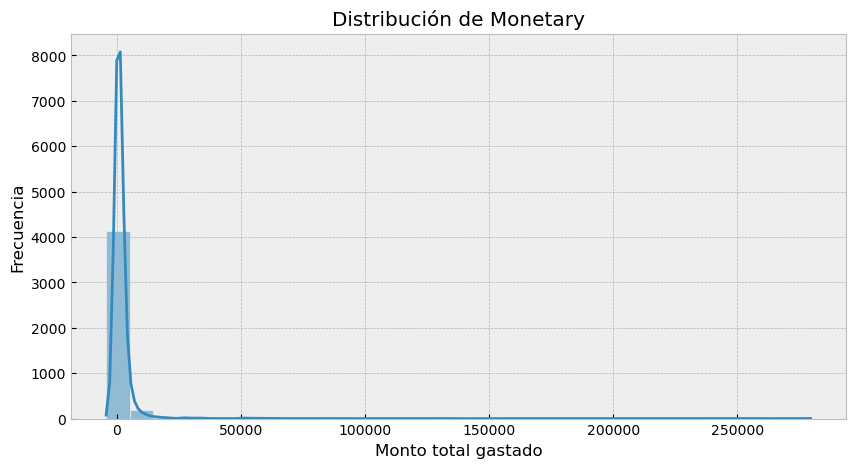

In [64]:
# Grafica un histograma de Monetary
plt.figure(figsize=(10,5))
sns.histplot(customer['MONETARY'], bins=30, kde=True)
plt.title('Distribución de Monetary')
plt.xlabel('Monto total gastado')
plt.ylabel('Frecuencia')
plt.show()


In [65]:
# Imprime la Estadística de Resumen para Monetary
customer['MONETARY'].describe()


count      4372.000000
mean       1898.459701
std        8219.345141
min       -4287.630000
25%         293.362500
50%         648.075000
75%        1611.725000
max      279489.020000
Name: MONETARY, dtype: float64

# Algoritmo k-Means

In [66]:
# Funcion para ordenar los clusters
def order_cluster(cluster_field_name, target_field_name, df, ascending):
    new_cluster_field_name = 'new_' + cluster_field_name
    df_new = df.groupby(cluster_field_name)[target_field_name].mean().reset_index()
    df_new = df_new.sort_values(by=target_field_name,ascending=ascending).reset_index(drop=True)
    df_new['index'] = df_new.index
    df_final = pd.merge(df,df_new[[cluster_field_name,'index']], on=cluster_field_name)
    df_final = df_final.drop([cluster_field_name],axis=1)
    df_final = df_final.rename(columns={"index":cluster_field_name})
    return df_final

In [67]:
rfm = customer[['RECENCY', 'FREQUENCY', 'MONETARY']]


In [68]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)


In [69]:
kmeans = KMeans(n_clusters=4, random_state=42)
customer['CLUSTER'] = kmeans.fit_predict(rfm_scaled)


In [70]:
customer = order_cluster('CLUSTER', 'RECENCY', customer, ascending=True)


In [71]:
customer = order_cluster('CLUSTER', 'RECENCY', customer, ascending=True)


In [72]:
customer = order_cluster('CLUSTER', 'MONETARY', customer, ascending=False)


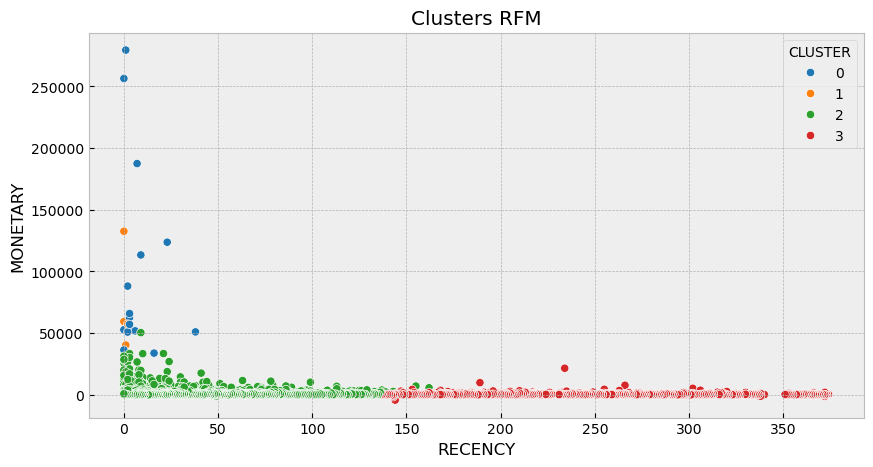

In [73]:
plt.figure(figsize=(10,5))
sns.scatterplot(
    data=customer,
    x='RECENCY',
    y='MONETARY',
    hue='CLUSTER',
    palette='tab10'
)
plt.title('Clusters RFM')
plt.show()


In [74]:
customer.groupby('CLUSTER')[['RECENCY','FREQUENCY','MONETARY']].mean()


,RECENCY,FREQUENCY,MONETARY
CLUSTER,,,
0,6.882353,54.882353,93683.153529
1,0.500000,167.500000,55084.095000
2,39.090321,5.614057,1809.233882
3,245.666063,1.846154,459.541105


# Elbow Method

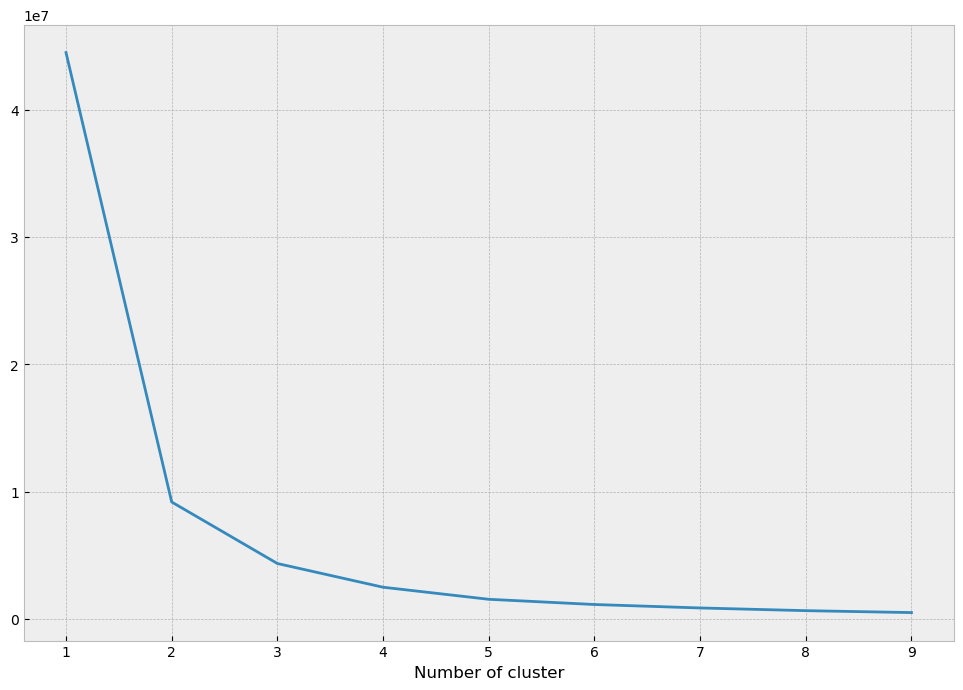

In [75]:
# Configuración inicial - Vamos a tomar como referencia el indicador de Recency
sse = {}
recency = customer[['RECENCY']].copy()

for k in range(1, 10):
    # Instancia el algoritmo de k-means iterando sobre k
    kmeans = KMeans(n_clusters=k, random_state=42)
    
    # Entrena el algoritmo
    kmeans.fit(recency)
    
    # Adjunta las etiquetas
    recency["clusters"] = kmeans.labels_
    
    # Adjunta la inercia o variación al arreglo sse
    sse[k] = kmeans.inertia_
    
# Grafico de codo (Elbow)
plt.figure(figsize=(12,8))
plt.plot(list(sse.keys()), list(sse.values()))
plt.xlabel("Number of cluster")
plt.show()


In [76]:
# Instanciar el algoritmo con 4 clusters para Recency 
kmeans = KMeans(n_clusters=4, random_state=42)

# Entrenar el algoritmo
kmeans.fit(customer[['RECENCY']])

# Obtener las predicciones
customer['RECENCY_CLUSTER'] = kmeans.predict(customer[['RECENCY']])

# Ordenar los clusters
customer = order_cluster('RECENCY_CLUSTER', 'RECENCY', customer, False)

# Estadística Descriptiva del cluster creado
customer.groupby('RECENCY_CLUSTER')['RECENCY'].mean()


RECENCY_CLUSTER
0    306.907197
1    185.367834
2     77.814920
3     17.397311
Name: RECENCY, dtype: float64

In [77]:
# Instanciar el algoritmo con 4 clusters para Frequency 
kmeans = KMeans(n_clusters=4, random_state=42)

# Entrenar el algoritmo
kmeans.fit(customer[['FREQUENCY']])

# Obtener las predicciones
customer['FREQUENCY_CLUSTER'] = kmeans.predict(customer[['FREQUENCY']])

# Ordenar los clusters 
customer = order_cluster('FREQUENCY_CLUSTER', 'FREQUENCY', customer, True)

# Estadística Descriptiva de los clusters
customer.groupby('FREQUENCY_CLUSTER')['FREQUENCY'].mean()

# Entrenar el algoritmo
kmeans.fit(customer[['FREQUENCY']])

# Obtener las predicciones
customer['FREQUENCY_CLUSTER'] = kmeans.predict(customer[['FREQUENCY']])

# Ordenar los clusters
customer = order_cluster('FREQUENCY_CLUSTER', 'FREQUENCY', customer, True)

# Estadística Descriptiva de los clusters
customer.groupby('FREQUENCY_CLUSTER')['FREQUENCY'].mean()

FREQUENCY_CLUSTER
0      2.945502
1     16.032389
2     58.325000
3    213.666667
Name: FREQUENCY, dtype: float64

In [78]:
# Instanciar el algoritmo con 4 clusters para Monetary 
kmeans = KMeans(n_clusters=4, random_state=42)

# Entrenar el algoritmo
kmeans.fit(customer[['MONETARY']])

# Obtener las predicciones
customer['MONETARY_CLUSTER'] = kmeans.predict(customer[['MONETARY']])

# Ordenar los clusters
customer = order_cluster('MONETARY_CLUSTER', 'MONETARY', customer, True)

# Estadística Descriptiva de los clusters
customer.groupby('MONETARY_CLUSTER')['MONETARY'].mean()

MONETARY_CLUSTER
0      1347.622983
1     35694.129167
2    114451.897500
3    241136.560000
Name: MONETARY, dtype: float64

# Score de Segmentación

In [79]:
# Vamos a crear nuestro score sumando el valor de cada uno de los clusters
customer['SCORE'] = customer['RECENCY_CLUSTER'] + customer['FREQUENCY_CLUSTER'] + customer['MONETARY_CLUSTER']

# Obtener el promedio para cada una de las métricas de las calificaciones creadas (Score)
customer['SCORE'].mean()


np.float64(2.2536596523330283)

In [80]:
# Crea una funcion que asigne lo siguiente: 
# Si score <= 1 entonces 'Low-Value', si score >1 y <=4 entonces 'Average', si score >4 y <=6 entonces 'Potential', por último si score >6 entonces 'High-Value'
def segment(score):
    if score <= 1:
        return 'Low-Value'
    elif score > 1 and score <= 4:
        return 'Average'
    elif score > 4 and score <= 6:
        return 'Potential'
    else:
        return 'High-Value'

# Crear una columna aplicando esta función al campo 'SCORE'
customer['SEGMENT'] = customer['SCORE'].apply(segment)


In [81]:
# Vamos a dar un vistazo a la tabla final
customer.head()


,CUSTOMER_ID,INVOICE_DATE,RECENCY,FREQUENCY,MONETARY,CLUSTER,RECENCY_CLUSTER,FREQUENCY_CLUSTER,MONETARY_CLUSTER,SCORE,SEGMENT
0,17850.0,2020-02-10 14:38:00,302,35,5288.63,3,0,1,0,1,Low-Value
1,13047.0,2020-11-08 12:10:00,31,18,3079.10,2,3,1,0,4,Average
2,12583.0,2020-12-07 08:07:00,2,18,7187.34,2,3,1,0,4,Average
3,13748.0,2020-09-05 09:45:00,95,5,948.25,2,2,0,0,2,Average
4,15100.0,2020-01-13 17:09:00,330,6,635.10,3,0,0,0,0,Low-Value


In [82]:
# Imprime la proporción o el total de clientes por segmento
customer['SEGMENT'].value_counts()


SEGMENT
Average       3164
Low-Value     1148
Potential       52
High-Value       8
Name: count, dtype: int64

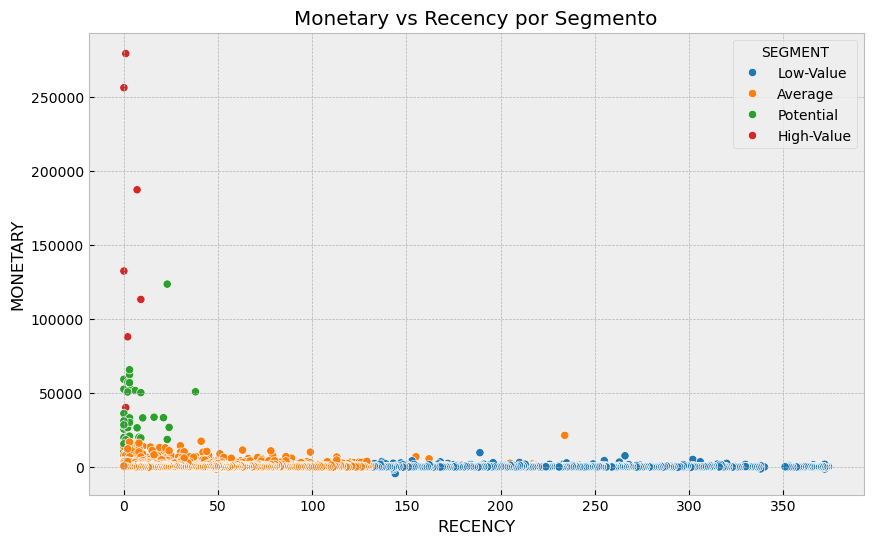

In [83]:
# Define un estilo 'bmh'
plt.style.use('bmh')


# Filtra los valores para RECENCY < 4000
filtered = customer[customer['RECENCY'] < 4000]


# Crea un grafico de dispersion de 'MONETARY' VS 'RECENCY' por Segmento
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=filtered,
    x='RECENCY',
    y='MONETARY',
    hue='SEGMENT',
    palette='tab10'
)
plt.title('Monetary vs Recency por Segmento')
plt.show()




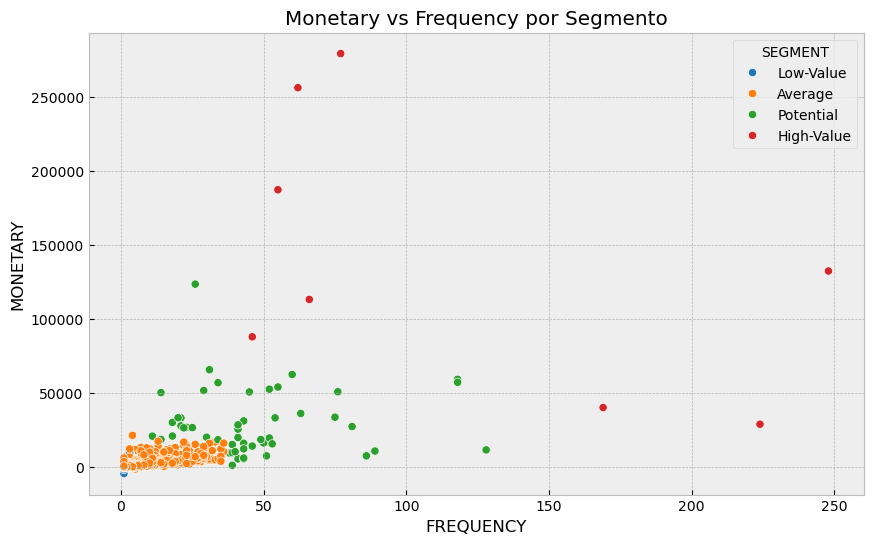

In [84]:
# Crea un grafico de dispersion de 'MONETARY' vs 'FREQUENCY' vs  por Segmento
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=filtered,
    x='FREQUENCY',
    y='MONETARY',
    hue='SEGMENT',
    palette='tab10'
)
plt.title('Monetary vs Frequency por Segmento')
plt.show()
